# 01 - Phase 1: data and geographic assessment (CDMX Urban Intelligence)

**Goal of this checkpoint.** Before designing the warehouse, show that the four sources can be integrated and that the chosen
geography is defensible.

| Checkpoint evidence | Where |
|---|---|
| Data-source inventory and initial profiling | sections 1 and 2 |
| Geographic-unit decision with justification | section 3 |
| Polygons loaded and inspected (CRS, validity, identifiers) | section 4 |
| Evidence that point data and polygons integrate | section 5 |
| Data-quality issues and assumptions | section 6 |
| Preliminary list of source variables for the KPIs | section 7 |

This notebook reads the **raw files** (`data/raw/`) because it happens before the warehouse exists. Nothing here modifies them.

In [1]:
import sys, warnings
from pathlib import Path

# make the project's src/ package importable when the notebook runs from notebooks/
SRC = Path.cwd().resolve().parent / "src"
sys.path.insert(0, str(SRC))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import config
import viz
import spatial_analysis as sa

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.width", 140)

OUT = config.ROOT / "outputs"
MAPS, FIGS, TABLES = OUT / "maps", OUT / "figures", OUT / "tables"
for d in (MAPS, FIGS, TABLES):
    d.mkdir(parents=True, exist_ok=True)

## 1. Data-source inventory

| Layer | Source | File | Original grain | Geographic key | Year |
|---|---|---|---|---|---|
| Demographic | INEGI Population and Housing Census 2020, "Principales resultados por AGEB y manzana urbana" | `RESAGEBURB_09CSV20.csv` | one row per entity, municipality, locality, AGEB and block (several levels mixed in one file) | `ENTIDAD+MUN+LOC+AGEB(+MZA)` | 2020 |
| Economic | INEGI DENUE, edition 11/2024 | `denue_inegi_09_.csv` | one row per establishment | AGEB and block codes plus latitude/longitude | 2024 |
| Geographic | INEGI Marco Geoestadistico (Census 2020 version), urban AGEB layer | `2020_1_09_A.shp` | one polygon per urban AGEB | `CVEGEO` (13 characters) | 2020 |
| Geographic | Same source, state layer (AGEE) | `2020_1_09_ENT.shp` | one polygon for Mexico City | `CVE_ENT` | 2020 |
| Public safety | FGJ CDMX, carpetas de investigacion (datos.cdmx.gob.mx) | `carpetasFGJ_acumulado_2025_01.csv` | one row per investigation file | latitude/longitude, alcaldia name | 2016 - Jan 2025 |

**Why 2024 for crime and businesses.** The crime file covers 2016 to January 2025. 2024 is the latest complete year and matches the latest
DENUE edition of that year. The Census is only available for 2020, so population is 4 years older than the other layers.

## 2. Profiling each source

### 2.1 Census 2020

In [2]:
NA = ["*", "N/D"]            # INEGI: '*' = confidential, 'N/D' = not available
census = pd.read_csv(config.CENSUS_CSV, encoding="utf-8-sig", dtype=str, na_values=NA)
levels = pd.Series({
    "Total rows in file": len(census),
    "Entity total": ((census.MUN == "000")).sum(),
    "Municipality total (alcaldia)": ((census.MUN != "000") & (census.LOC == "0000")).sum(),
    "Locality total": ((census.LOC != "0000") & (census.AGEB == "0000")).sum(),
    "AGEB total": ((census.AGEB != "0000") & (census.MZA == "000")).sum(),
    "Block (manzana)": ((census.MZA != "000")).sum(),
}).to_frame("rows")
display(levels)
display(Markdown(f"The file has **{census.shape[1]} columns**. The rows mix several levels, so the cleaning rule selects AGEB totals "
                 "(`MZA = 000` and `AGEB != 0000`) to avoid double counting."))

,rows
Total rows in file,68941
Entity total,1
Municipality total (alcaldia),16
Locality total,35
AGEB total,2433
Block (manzana),66456


The file has **230 columns**. The rows mix several levels, so the cleaning rule selects AGEB totals (`MZA = 000` and `AGEB != 0000`) to avoid double counting.

In [3]:
ageb_rows = census[(census.ENTIDAD == "09") & (census.MZA == "000") & (census.AGEB != "0000")]
kpi_vars = ["POBTOT", "P_12YMAS", "PEA", "P_0A2", "P_3A5", "P_6A11", "P_12A14", "P_15A17", "P_18A24", "P_60YMAS", "VIVTOT"]
missing = pd.DataFrame({
    "AGEB level: share suppressed or missing": ageb_rows[kpi_vars].isna().mean(),
    "Block level: share suppressed or missing": census[census.MZA != "000"][kpi_vars].isna().mean(),
})
display(Markdown(f"AGEB totals for CDMX: **{len(ageb_rows):,}** rows, **{pd.to_numeric(ageb_rows.POBTOT).sum():,.0f}** inhabitants "
                 f"across **{ageb_rows.MUN.nunique()}** alcaldias."))
missing.style.format("{:.1%}")

AGEB totals for CDMX: **2,433** rows, **9,145,632** inhabitants across **16** alcaldias.

,AGEB level: share suppressed or missing,Block level: share suppressed or missing
POBTOT,0.0%,0.0%
P_12YMAS,0.4%,2.5%
PEA,0.4%,2.6%
P_0A2,1.1%,32.1%
P_3A5,0.8%,29.0%
P_6A11,0.9%,16.9%
P_12A14,0.9%,26.7%
P_15A17,0.8%,25.9%
P_18A24,0.6%,10.9%
P_60YMAS,0.7%,7.2%


The suppression rate is small at AGEB level and large at block level (INEGI hides values for blocks with few dwellings to protect
privacy). This matters for the choice of geographic unit in section 3.

### 2.2 DENUE 11/2024

In [4]:
denue = pd.read_csv(config.DENUE_CSV, encoding="latin-1", dtype=str)
for c in denue.columns:
    denue[c] = denue[c].str.strip()
summary = pd.Series({
    "Establishments": len(denue),
    "Columns": denue.shape[1],
    "Duplicate ids": denue.id.duplicated().sum(),
    "Missing latitude/longitude": (denue.latitud.isna() | denue.longitud.isna()).sum(),
    "Missing AGEB code": denue.ageb.isna().sum(),
    "Missing SCIAN code (codigo_act)": denue.codigo_act.isna().sum(),
    "Latest registration month (fecha_alta)": denue.fecha_alta.max(),
}).to_frame("value")
display(summary)
size = denue.per_ocu.value_counts().to_frame("establishments"); size["share"] = size.establishments / size.establishments.sum()
sector = denue.codigo_act.str[:2].value_counts().head(8).rename_axis("SCIAN sector (first 2 digits)").to_frame("establishments")
display(size.style.format({"share": "{:.1%}"})); sector

,value
Establishments,458228
Columns,42
Duplicate ids,0
Missing latitude/longitude,0
Missing AGEB code,0
Missing SCIAN code (codigo_act),0
Latest registration month (fecha_alta),2024-11


,establishments,share
per_ocu,,
0 a 5 personas,388695,84.8%
6 a 10 personas,31637,6.9%
11 a 30 personas,21994,4.8%
31 a 50 personas,5473,1.2%
51 a 100 personas,4932,1.1%
101 a 250 personas,3221,0.7%
251 y más personas,2276,0.5%


,establishments
SCIAN sector (first 2 digits),
46,207181
81,66243
72,56932
62,22585
31,17831
43,13582
52,11133
54,10990


### 2.3 FGJ crime file

In [5]:
crime = pd.read_csv(config.CRIME_CSV, dtype=str, low_memory=False,
                    usecols=["fecha_hecho", "hora_hecho", "delito", "categoria_delito",
                             "alcaldia_hecho", "latitud", "longitud"])
crime["fh"] = pd.to_datetime(crime.fecha_hecho, errors="coerce", format="mixed")
per_year = crime.fh.dt.year.value_counts().sort_index()
per_year = per_year[per_year.index >= 2015].astype(int).to_frame("files by incident year")
per_year.index = per_year.index.astype(int).astype(str).rename("incident year")
display(Markdown(f"The file has **{len(crime):,}** rows. Incident dates run from the 1900s (data-entry errors) to January 2025; "
                 "the filing year differs from the incident year, so the cleaning step filters by **incident date**."))
per_year

The file has **2,098,743** rows. Incident dates run from the 1900s (data-entry errors) to January 2025; the filing year differs from the incident year, so the cleaning step filters by **incident date**.

,files by incident year
incident year,
2015,16480
2016,195651
2017,228263
2018,255689
2019,246634
2020,206379
2021,228180
2022,237868
2023,237440


In [6]:
c24 = crime[crime.fh.dt.year == 2024].copy()
c24["lat"] = pd.to_numeric(c24.latitud, errors="coerce"); c24["lon"] = pd.to_numeric(c24.longitud, errors="coerce")
prof = pd.Series({
    "Incident files in 2024": len(c24),
    "Non-criminal events ('HECHO NO DELICTIVO')": (c24.categoria_delito == "HECHO NO DELICTIVO").sum(),
    "Missing coordinates": c24.lat.isna().sum(),
    "Distinct offense names (delito)": c24.delito.nunique(),
    "Distinct FGJ categories": c24.categoria_delito.nunique(),
}).to_frame("value")
display(prof)
share = (c24.categoria_delito.value_counts(normalize=True).head(4)).to_frame("share of 2024 files")
display(Markdown("The FGJ category is too coarse for analysis (one bucket holds most files), so the ETL builds its own crime groups from the offense name."))
share.style.format("{:.1%}")

,value
Incident files in 2024,216965
Non-criminal events ('HECHO NO DELICTIVO'),6504
Missing coordinates,13678
Distinct offense names (delito),280
Distinct FGJ categories,16


The FGJ category is too coarse for analysis (one bucket holds most files), so the ETL builds its own crime groups from the offense name.

,share of 2024 files
categoria_delito,
DELITO DE BAJO IMPACTO,85.9%
ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIOLENCIA,3.7%
ROBO DE VEHÍCULO CON Y SIN VIOLENCIA,3.3%
HECHO NO DELICTIVO,3.0%


## 3. Choosing the geographic unit

The sources use different geographic representations: the Census reports **areas** (AGEB, blocks, municipalities), DENUE reports
**points plus area codes**, and the crime file reports **points only**. A unit is useful only if (a) an **official polygon** exists,
(b) the Census has indicators for it, (c) points can be assigned to it by a spatial join, and (d) there are enough units, each with
enough events, for statistics.

In [7]:
blocks = census[(census.ENTIDAD == "09") & (census.MZA != "000")]
n_blocks = len(blocks)
n_crime = int((c24.lat.notna() & (c24.categoria_delito != "HECHO NO DELICTIVO")).sum())
n_ageb = len(ageb_rows)
pop = pd.to_numeric(ageb_rows.POBTOT)
block_supp = blocks[["POBTOT", "PEA", "P_60YMAS"]].isna().mean().mean()
ageb_supp = ageb_rows[["POBTOT", "PEA", "P_60YMAS"]].isna().mean().mean()

candidates = pd.DataFrame([
    {"Candidate unit": "Alcaldia (AGEM)", "Units": 16, "Official polygons": "Yes (INEGI AGEM layer)",
     "Census indicators": "Yes", "Crime points per unit (avg)": n_crime / 16,
     "Suppressed census values": "~0%", "Verdict": "Too coarse: 16 units cannot support Moran or LISA"},
    {"Candidate unit": "AGEB urbana", "Units": n_ageb, "Official polygons": "Yes (INEGI AGEB layer)",
     "Census indicators": "Yes", "Crime points per unit (avg)": n_crime / n_ageb,
     "Suppressed census values": f"{ageb_supp:.1%}", "Verdict": "Selected"},
    {"Candidate unit": "Block (manzana)", "Units": n_blocks, "Official polygons": "Yes (INEGI block layer, not used)",
     "Census indicators": "Yes, heavily suppressed", "Crime points per unit (avg)": n_crime / n_blocks,
     "Suppressed census values": f"{block_supp:.1%}", "Verdict": "Too fine: sparse crime counts and suppressed census data"},
    {"Candidate unit": "Colonia", "Units": c24.alcaldia_hecho.nunique(), "Official polygons": "No INEGI polygons",
     "Census indicators": "No (Census is not published by colonia)", "Crime points per unit (avg)": np.nan,
     "Suppressed census values": "n/a", "Verdict": "Rejected: no official boundary and no census data"},
]).set_index("Candidate unit")
candidates["Units"] = candidates["Units"].where(candidates.index != "Colonia", np.nan)
candidates.style.format({"Units": "{:,.0f}", "Crime points per unit (avg)": "{:,.1f}"}, na_rep="n/a")

,Units,Official polygons,Census indicators,Crime points per unit (avg),Suppressed census values,Verdict
Candidate unit,,,,,,
Alcaldia (AGEM),16,Yes (INEGI AGEM layer),Yes,"12,378.6",~0%,Too coarse: 16 units cannot support Moran or LISA
AGEB urbana,"2,433",Yes (INEGI AGEB layer),Yes,81.4,0.4%,Selected
Block (manzana),"66,456","Yes (INEGI block layer, not used)","Yes, heavily suppressed",3.0,3.3%,Too fine: sparse crime counts and suppressed census data
Colonia,n/a,No INEGI polygons,No (Census is not published by colonia),n/a,n/a,Rejected: no official boundary and no census data


In [8]:
display(Markdown(
    f"**Decision: urban AGEB.** It is the finest unit for which the Census publishes a complete set of indicators "
    f"({ageb_supp:.1%} of values suppressed against {block_supp:.1%} for blocks), INEGI provides official polygons whose 13-character "
    f"`CVEGEO` key matches the Census rows, DENUE carries the AGEB code and coordinates, and crime points join by location. "
    f"With **{n_ageb:,} units** averaging about {n_crime / n_ageb:,.0f} crime files and {pop.mean():,.0f} residents each, there is enough "
    f"resolution to compare areas and enough events per unit for rates and spatial statistics. "
    f"Blocks would average only {n_crime / n_blocks:,.1f} crime files each, and alcaldias give just 16 observations. "
    "The unit has known limits (AGEB differ in size and are an administrative mosaic), discussed in section 6."))

**Decision: urban AGEB.** It is the finest unit for which the Census publishes a complete set of indicators (0.4% of values suppressed against 3.3% for blocks), INEGI provides official polygons whose 13-character `CVEGEO` key matches the Census rows, DENUE carries the AGEB code and coordinates, and crime points join by location. With **2,433 units** averaging about 81 crime files and 3,759 residents each, there is enough resolution to compare areas and enough events per unit for rates and spatial statistics. Blocks would average only 3.0 crime files each, and alcaldias give just 16 observations. The unit has known limits (AGEB differ in size and are an administrative mosaic), discussed in section 6.

## 4. Loading and inspecting the polygons

In [9]:
ageb = gpd.read_file(config.AGEB_SHP)
epsg = ageb.crs.to_epsg()
inspect = pd.Series({
    "Polygons": len(ageb),
    "CRS name": ageb.crs.name,
    "EPSG code (if identifiable)": epsg if epsg else "custom Lambert Conformal Conic, ITRF2008",
    "Geometry types": ", ".join(ageb.geom_type.unique()),
    "Invalid geometries": int((~ageb.is_valid).sum()),
    "Empty geometries": int(ageb.is_empty.sum()),
    "Unique CVEGEO": bool(ageb.CVEGEO.is_unique),
    "CVEGEO length (characters)": ", ".join(map(str, sorted(ageb.CVEGEO.str.len().unique()))),
    "Alcaldias (CVE_MUN)": ageb.CVE_MUN.nunique(),
}).to_frame("value")
display(inspect)
display(ageb.drop(columns="geometry").head(3))
print("Identifier anatomy: CVEGEO = CVE_ENT (2) + CVE_MUN (3) + CVE_LOC (4) + CVE_AGEB (4):",
      (ageb.CVEGEO == ageb.CVE_ENT + ageb.CVE_MUN + ageb.CVE_LOC + ageb.CVE_AGEB).all())

,value
Polygons,2431
CRS name,MEXICO_ITRF_2008_LCC
EPSG code (if identifiable),"custom Lambert Conformal Conic, ITRF2008"
Geometry types,Polygon
Invalid geometries,0
Empty geometries,0
Unique CVEGEO,True
CVEGEO length (characters),13
Alcaldias (CVE_MUN),16


,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,CVE_AGEB
0,0901000011716,09,010,0001,1716
1,0901000012150,09,010,0001,2150
2,0901000011133,09,010,0001,1133


Identifier anatomy: CVEGEO = CVE_ENT (2) + CVE_MUN (3) + CVE_LOC (4) + CVE_AGEB (4): True


In [10]:
area_km2 = ageb.to_crs(sa.METRIC_EPSG).area / 1e6
display(Markdown(f"AGEB area (km2, projected to UTM 14N): median **{area_km2.median():.2f}**, "
                 f"90th percentile **{area_km2.quantile(.9):.2f}**, largest **{area_km2.max():.1f}**. "
                 "Sizes are very uneven, which matters for the spatial-neighbour rule."))
ageb_rows = ageb_rows.assign(cvegeo=ageb_rows.ENTIDAD + ageb_rows.MUN + ageb_rows.LOC + ageb_rows.AGEB)
join = pd.Series({
    "Census AGEB rows": len(ageb_rows),
    "Polygons": len(ageb),
    "Census rows with a polygon": int(ageb_rows.cvegeo.isin(ageb.CVEGEO).sum()),
    "Polygons with a census row": int(ageb.CVEGEO.isin(ageb_rows.cvegeo).sum()),
}).to_frame("count")
orphans = ageb_rows[~ageb_rows.cvegeo.isin(ageb.CVEGEO)][["cvegeo", "NOM_MUN", "POBTOT"]]
display(join)
display(Markdown("Census rows without a polygon (excluded from the warehouse, with their population):"))
orphans

AGEB area (km2, projected to UTM 14N): median **0.23**, 90th percentile **0.62**, largest **7.4**. Sizes are very uneven, which matters for the spatial-neighbour rule.

,count
Census AGEB rows,2433
Polygons,2431
Census rows with a polygon,2431
Polygons with a census row,2431


Census rows without a polygon (excluded from the warehouse, with their population):

,cvegeo,NOM_MUN,POBTOT
48557,0901101101107,Tláhuac,3050
53813,0901201351227,Tlalpan,4058


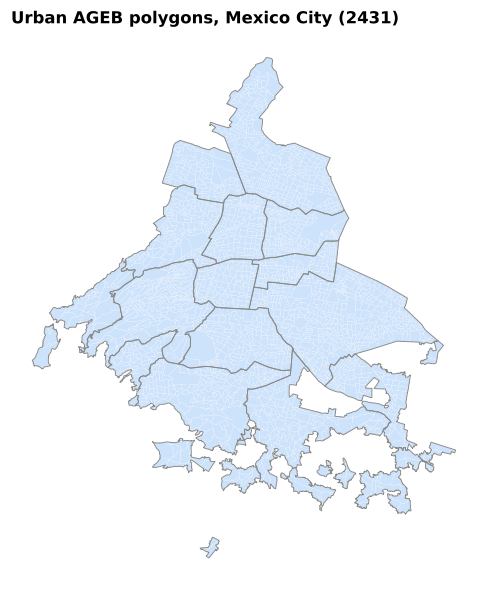

In [11]:
fig, ax = plt.subplots(figsize=(6, 6.5))
ageb.to_crs(4326).plot(ax=ax, color="#cde2fb", edgecolor="white", linewidth=0.1)
ageb.to_crs(4326).dissolve(by="CVE_MUN").boundary.plot(ax=ax, color=viz.BOUNDARY, linewidth=0.6)
ax.set_axis_off(); ax.set_aspect("equal")
ax.set_title("Urban AGEB polygons, Mexico City (%d)" % len(ageb), loc="left", fontweight="bold")
fig.savefig(config.ROOT / "outputs" / "maps" / "map_ageb_polygons.png", bbox_inches="tight", facecolor="white")
plt.show()

## 5. Point-to-polygon integration test

The crime file has latitude/longitude. We (1) convert them to point geometries in EPSG:4326, (2) reproject to the polygon CRS,
(3) assign each point to the AGEB that contains it with a spatial join, and (4) measure how many points land in a polygon.
The same test is repeated for DENUE, where the AGEB code gives an independent check.

In [12]:
import shapely

state = gpd.read_file(config.AGEE_SHP).to_crs(4326).geometry.union_all()

c = c24[(c24.categoria_delito != "HECHO NO DELICTIVO") & c24.lat.notna() & c24.lon.notna()].copy()
inside_cdmx = shapely.contains_xy(state, c.lon.values, c.lat.values)
pts = gpd.GeoDataFrame(c[inside_cdmx], geometry=gpd.points_from_xy(c.lon[inside_cdmx], c.lat[inside_cdmx]), crs=4326)
pts = pts.to_crs(ageb.crs)                                           # same CRS as the polygons
joined = gpd.sjoin(pts, ageb[["CVEGEO", "geometry"]], how="left", predicate="within")

result = pd.Series({
    "2024 criminal files": int((c24.categoria_delito != "HECHO NO DELICTIVO").sum()),
    "With coordinates": len(c),
    "Coordinates inside the CDMX polygon": int(inside_cdmx.sum()),
    "Assigned to exactly one AGEB": int(joined.CVEGEO.notna().sum()),
    "Inside CDMX but in no urban AGEB (rural land)": int(joined.CVEGEO.isna().sum()),
    "Points matched to more than one polygon": int(joined.index.duplicated().sum()),
}).to_frame("points")
result["share of 2024 criminal files"] = result.points / result.points.iloc[0]
result.style.format({"points": "{:,.0f}", "share of 2024 criminal files": "{:.1%}"})

,points,share of 2024 criminal files
2024 criminal files,"210,461",100.0%
With coordinates,"198,058",94.1%
Coordinates inside the CDMX polygon,"198,007",94.1%
Assigned to exactly one AGEB,"197,518",93.9%
Inside CDMX but in no urban AGEB (rural land),489,0.2%
Points matched to more than one polygon,0,0.0%


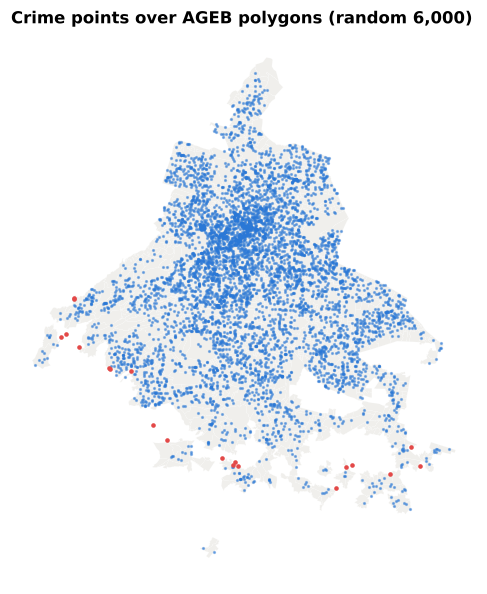

Blue points fall inside an AGEB polygon; red points are inside CDMX but in no urban AGEB (conservation land and rural areas in the south and west).

In [13]:
sample_pts = joined.sample(6000, random_state=1).to_crs(4326)
fig, ax = plt.subplots(figsize=(6, 6.5))
ageb.to_crs(4326).plot(ax=ax, color="#f0efec", edgecolor="white", linewidth=0.1)
sample_pts[sample_pts.CVEGEO.notna()].plot(ax=ax, markersize=1.2, color="#2a78d6", alpha=0.5)
sample_pts[sample_pts.CVEGEO.isna()].plot(ax=ax, markersize=4, color="#e34948")
ax.set_axis_off(); ax.set_aspect("equal")
ax.set_title("Crime points over AGEB polygons (random 6,000)", loc="left", fontweight="bold")
fig.savefig(config.ROOT / "outputs" / "maps" / "map_crime_points_integration.png", bbox_inches="tight", facecolor="white")
plt.show()
display(Markdown("Blue points fall inside an AGEB polygon; red points are inside CDMX but in no urban AGEB (conservation land and rural areas in the south and west)."))

In [14]:
d = denue.copy()
d["lat"] = pd.to_numeric(d.latitud, errors="coerce"); d["lon"] = pd.to_numeric(d.longitud, errors="coerce")
d = d.dropna(subset=["lat", "lon"])
d = d[shapely.contains_xy(state, d.lon.values, d.lat.values)]
dpts = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(d.lon, d.lat), crs=4326).to_crs(ageb.crs)
dj = gpd.sjoin(dpts, ageb[["CVEGEO", "geometry"]], how="left", predicate="within")
dj["code_key"] = dj.cve_ent + dj.cve_mun + dj.cve_loc + dj.ageb
both = dj[dj.CVEGEO.notna()]
den = pd.DataFrame({
    "value": [len(dj), int(dj.CVEGEO.notna().sum()), dj.CVEGEO.notna().mean(), (both.code_key == both.CVEGEO).mean()]},
    index=["DENUE establishments with valid coordinates inside CDMX", "Assigned to an AGEB by location",
           "Share assigned by location", "Agreement between DENUE AGEB code and location"])
den["shown as"] = ["count", "count", "percent", "percent"]
den["value"] = [f"{v:,.0f}" if k == "count" else f"{v:.2%}" for v, k in zip(den.value, den["shown as"])]
den[["value"]]

,value
DENUE establishments with valid coordinates inside CDMX,"458,193"
Assigned to an AGEB by location,"456,724"
Share assigned by location,99.68%
Agreement between DENUE AGEB code and location,99.78%


In [15]:
display(Markdown(
    f"**Conclusion.** {joined.CVEGEO.notna().sum()/len(c):.1%} of the georeferenced crime points ({joined.CVEGEO.notna().mean():.2%} of those inside CDMX) fall inside exactly one AGEB polygon, none matches two, "
    f"and the DENUE AGEB code agrees with the spatial join for {(both.code_key == both.CVEGEO).mean():.1%} of establishments. "
    "Points and polygons integrate cleanly; the unmatched points lie in rural land outside the urban AGEB layer. "
    "The warehouse repeats this join in PostGIS so the result is reproducible from SQL."))

**Conclusion.** 99.7% of the georeferenced crime points (99.75% of those inside CDMX) fall inside exactly one AGEB polygon, none matches two, and the DENUE AGEB code agrees with the spatial join for 99.8% of establishments. Points and polygons integrate cleanly; the unmatched points lie in rural land outside the urban AGEB layer. The warehouse repeats this join in PostGIS so the result is reproducible from SQL.

## 6. Data-quality issues, assumptions and integration decisions

| Area | Issue found | Decision |
|---|---|---|
| Census | `*` (confidential) and `N/D` codes instead of numbers | Converted to NULL, never to zero; rates need a minimum population |
| Census | File mixes entity, municipality, locality, AGEB and block rows | Keep only AGEB totals (`MZA = 000`, `AGEB != 0000`) |
| Census | Age group 25-59 not published | Derived as total minus the other groups; NULL if any part is suppressed |
| Census / polygons | 2 Census AGEB have no polygon | Excluded from the warehouse (documented, under 0.1% of population) |
| DENUE | A few establishments carry placeholder coordinates outside CDMX | Flagged `invalid`; kept, and assigned to an AGEB by their code when it exists |
| DENUE | Edition 11/2024 vs Census 2020 | Accepted; businesses reflect 2024, population 2020 |
| DENUE | AGEB codes may follow a newer boundary version | Spatial join is primary; the code is only a fallback |
| Crime | No incident id in the file | `source_id` = row number of the raw file for traceability |
| Crime | Filing year differs from incident year; mixed date formats | Filter by incident date (`fecha_hecho`), parse with mixed formats |
| Crime | Non-criminal events included | Removed (`HECHO NO DELICTIVO`) |
| Crime | About 6% without coordinates | Not loaded to the fact table; counted in the QA report |
| Crime | Time of day heaped on round hours and noon | Analyse by time band, not by single hour |
| Crime | FGJ category too coarse | ETL builds 10 analytical crime groups from the offense name |
| Crime | Recorded files, not all crimes; reporting differs by area | Stated as a limitation of every crime result |
| Geography | AGEB are unequal in size (modifiable areal unit problem) | Use density and rates, and test two neighbour rules |

## 7. Source variables required by each KPI

| KPI | Source variables | Source |
|---|---|---|
| Total population | `POBTOT` | Census |
| Population density | `POBTOT`, polygon area | Census, polygons |
| Economically active population rate | `PEA`, `P_12YMAS` | Census |
| Population by age group | `P_0A2`, `P_3A5`, `P_6A11`, `P_12A14`, `P_15A17`, `P_18A24`, `P_60YMAS` (25-59 derived from `POBTOT`) | Census |
| Total businesses, business density | establishment id, coordinates, AGEB code | DENUE, polygons |
| Businesses per 1,000 residents | businesses, `POBTOT` | DENUE, Census |
| Retail and service density | `codigo_act` (SCIAN), coordinates | DENUE, polygons |
| Dominant economic activity | `codigo_act` | DENUE |
| Business size (descriptive) | `per_ocu` | DENUE |
| Total crime incidents, crime rate | `latitud`, `longitud`, `fecha_hecho`, `POBTOT` | FGJ, polygons, Census |
| Incidents by type and time | `delito`, `categoria_delito`, `fecha_hecho`, `hora_hecho` | FGJ |
| Crime relative to business activity | crime incidents, businesses | FGJ, DENUE |

## 8. Conclusion of Phase 1

* The four sources can be integrated: Census and polygons share the `CVEGEO` key, and both point layers join to polygons by location.
* The **urban AGEB** is the selected unit: 2,431 areas with official polygons, complete census indicators and enough events per area.
* The main limitations are the 2020-vs-2024 gap, the heaping and missing coordinates of the crime file, and the unequal size of AGEB.

Next: `sql/01_schema.sql` implements the dimensional model and `src/` the reproducible ETL (Phase 2).